In [1]:
import functools
import warnings

import botocore
import boto3
from iterpop import iterpop as ip
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from dishpylib.pyhelpers import fit_control_t_distns

warnings.filterwarnings("ignore")


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmvatxw
interpreter: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
notebook name: 2025-12-04-cryptic-complexity
notebook path: /home/runner/work/oee4/oee4/binder/2025-12-04-cryptic-complexity.ipynb
revision: bdac574
timestamp: 2026-01-20T00:53:37Z00:00

IPython==7.16.1
packaging==25.0


In [4]:
teeplot_subdir = "2025-12-04-cryptic-complexity"


In [5]:
@functools.lru_cache
def get_control_t_distns( bucket, prefix, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/{prefix}control-competitions/stage={2 + bool(prefix)}+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 1
    ].copy())


In [6]:
def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: scipy_stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [7]:
bucket = "prq49"
dfs = []
for prefix in [
    "cryptic-",
    "",
]:
    if "step" in bucket:
        step = int(bucket.split("-step")[-1]) + 1
    else:
        step = 0
    if "restint" in bucket:
        kind = bucket.split("-")[3]
    else:
        kind = None
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    for stint in tqdm(range(101)):
        try:
            series_profiles, = bucket_handle.objects.filter(
                Prefix=f'endeavor=16/{prefix}variant-competitions/stage=3+what=collated/stint={stint}/',
            )
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
            control_fits_df = get_control_t_distns(bucket, prefix, 16, stint)
            df = pd.read_csv(
                f's3://{bucket}/{series_profiles.key}',
                compression='xz',
            )
            df = df[df["Competition Series"] == 16005]
            df = df.groupby("genome variation").mean(numeric_only=True).reset_index()
            df["Stint"] = stint
            dfdigest = "{:x}".format( hash_pandas_object( df ).sum() )
            df = preprocess_competition_fitnesses(df, control_fits_df)

            df = df.copy()
            df["bucket"] = bucket
            df["variant"] = {"cryptic-": "skeleton", "": "wildtype"}[prefix]
            dfs.append(df)
        except Exception as e:
            print(e)
            print(f"Skipping {bucket=}, {stint=}, {prefix=}")


100%|██████████| 101/101 [01:01<00:00,  1.64it/s]


In [8]:
df = pd.concat(dfs)


In [9]:
df.to_csv("replays-mutagenized.csv")


In [10]:
pd.options.display.max_columns = None


In [11]:
dfx = df[
    df["Root ID"] == 1
].groupby(["Stint", "bucket", "variant"]).agg(
    {
        "Is More Fit": "sum",
        "Is Less Fit": "sum",
        "Is Neutral": "sum",
        "genome variation": "count",
    },
)
dfx


Is More Fit  Is Less Fit  Is Neutral  genome variation
Stint bucket variant                                                         
0     prq49  skeleton            3           10          25                38
             wildtype            2            6           8                16
1     prq49  skeleton            8            8          32                48
             wildtype            3            8          37                48
2     prq49  skeleton            2           26          15                43
...                            ...          ...         ...               ...
98    prq49  wildtype            0           34         674               708
99    prq49  skeleton            2           49          59               110
             wildtype            2           34          74               110
100   prq49  skeleton            0           41         352               393
             wildtype            0           35         620               655

[202 rows x 4 columns]

In [12]:
dfx = dfx.reset_index(drop=False)


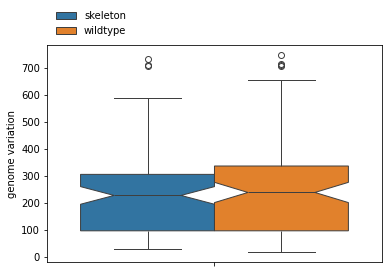

In [13]:
ax = sns.boxplot(
    data=dfx,
    # x="Stint",
    y="genome variation",
    hue="variant",
    notch=True,
    # legend=False,
)
sns.move_legend(
    ax,
    "lower left",
    bbox_to_anchor=(0, 1),
    title="",
    frameon=False,
)


In [14]:
dfx["epoch"] = np.minimum(dfx["Stint"], 99) // 20


<AxesSubplot:xlabel='epoch', ylabel='Is Less Fit'>

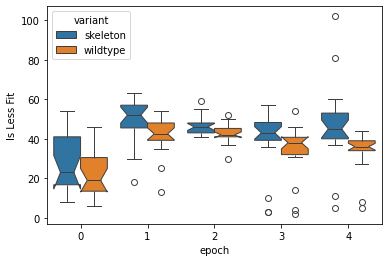

In [15]:
sns.boxplot(
    data=dfx,
    x="epoch",
    y="Is Less Fit",
    hue="variant",
    notch=True,
)


teeplots/2025-12-04-cryptic-complexity/hue=variant+style=variant+viz=lineplot+x=stint+y=is-less-fit+ext=.pdf
teeplots/2025-12-04-cryptic-complexity/hue=variant+style=variant+viz=lineplot+x=stint+y=is-less-fit+ext=.png


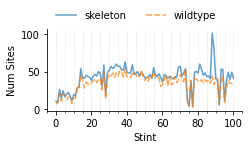

teeplots/2025-12-04-cryptic-complexity/hue=variant+style=variant+viz=lineplot+x=stint+y=is-more-fit+ext=.pdf
teeplots/2025-12-04-cryptic-complexity/hue=variant+style=variant+viz=lineplot+x=stint+y=is-more-fit+ext=.png


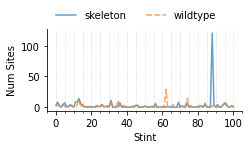

teeplots/2025-12-04-cryptic-complexity/hue=variant+style=variant+viz=lineplot+x=stint+y=is-neutral+ext=.pdf
teeplots/2025-12-04-cryptic-complexity/hue=variant+style=variant+viz=lineplot+x=stint+y=is-neutral+ext=.png


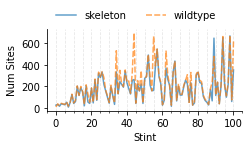

In [16]:
for y in ["Is Less Fit", "Is More Fit", "Is Neutral"]:
    with tp.teed(
        sns.lineplot,
        data=dfx,
        x="Stint",
        y=y,
        alpha=0.7,
        hue="variant",
        style="variant",
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        ax.figure.set_size_inches(3.5, 1.5)
        ax.set_ylabel("Num Sites")
        sns.move_legend(
            ax,
            "lower left",
            bbox_to_anchor=(0, 1),
            title="",
            frameon=False,
            ncol=2,
        )
        sns.despine(ax=ax)
        ax.xaxis.set_minor_locator(MultipleLocator(5))
        ax.grid(axis="x", which="minor", linestyle="--", alpha=0.3)
        ax.grid(axis="x", which="major", linestyle="--", alpha=0.3)


teeplots/2025-12-04-cryptic-complexity/hue=variant+site_max=1000+site_min=0+stint_max=100+stint_min=30+viz=lmplot+x=stint+y=is-less-fit+ext=.pdf
teeplots/2025-12-04-cryptic-complexity/hue=variant+site_max=1000+site_min=0+stint_max=100+stint_min=30+viz=lmplot+x=stint+y=is-less-fit+ext=.png


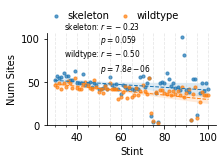

teeplots/2025-12-04-cryptic-complexity/hue=variant+site_max=80+site_min=20+stint_max=100+stint_min=30+viz=lmplot+x=stint+y=is-less-fit+ext=.pdf
teeplots/2025-12-04-cryptic-complexity/hue=variant+site_max=80+site_min=20+stint_max=100+stint_min=30+viz=lmplot+x=stint+y=is-less-fit+ext=.png


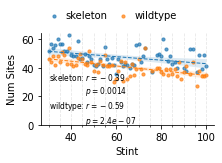

teeplots/2025-12-04-cryptic-complexity/hue=variant+site_max=80+site_min=20+stint_max=100+stint_min=40+viz=lmplot+x=stint+y=is-less-fit+ext=.pdf
teeplots/2025-12-04-cryptic-complexity/hue=variant+site_max=80+site_min=20+stint_max=100+stint_min=40+viz=lmplot+x=stint+y=is-less-fit+ext=.png


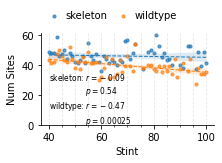

teeplots/2025-12-04-cryptic-complexity/hue=variant+site_max=1000+site_min=0+stint_max=100+stint_min=40+viz=lmplot+x=stint+y=is-less-fit+ext=.pdf
teeplots/2025-12-04-cryptic-complexity/hue=variant+site_max=1000+site_min=0+stint_max=100+stint_min=40+viz=lmplot+x=stint+y=is-less-fit+ext=.png


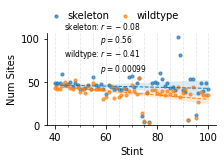

In [17]:
for stint_min, stint_max, site_min, site_max in [
    (30, 100, 0, 1000),
    (30, 100, 20, 80),
    (40, 100, 20, 80),
    (40, 100, 0, 1000),
]:
    with tp.teed(
        sns.lmplot,
        data=dfx[
            (dfx["Stint"] >= stint_min)
            & (dfx["Stint"] <= stint_max)
            & (dfx["Is Less Fit"] <= site_max)
            & (dfx["Is Less Fit"] >= site_min)
        ],
        x="Stint",
        y="Is Less Fit",
        hue="variant",
        line_kws={
            "lw": 1,
            "ls": "--",
        },
        scatter_kws={"s": 10, "alpha": 0.7},
        teeplot_outattrs={
            "stint_min": stint_min,
            "stint_max": stint_max,
            "site_min": site_min,
            "site_max": site_max,
        },
        teeplot_subdir=teeplot_subdir,
    ) as g:
        g.figure.set_size_inches(3.5, 1.5)
        for ax in g.axes.flat:
            ax.set_ylim(0, None)
        g.set_ylabels("Num Sites")
        sns.move_legend(
            g,
            "lower left",
            bbox_to_anchor=(0.1, 1),
            title="",
            ncol=2,
            columnspacing=0.5,
            handletextpad=0.2,
            frameon=False,
        )
        reg = {
            variant: scipy_stats.linregress(
                dfx[
                    (dfx["Stint"] >= stint_min)
                    & (dfx["Stint"] <= stint_max)
                    & (dfx["Is Less Fit"] <= site_max)
                    & (dfx["Is Less Fit"] >= site_min)
                    & (dfx["variant"] == variant)
                ]["Stint"],
                dfx[
                    (dfx["Stint"] >= stint_min)
                    & (dfx["Stint"] <= stint_max)
                    & (dfx["Is Less Fit"] <= site_max)
                    & (dfx["Is Less Fit"] >= site_min)
                    & (dfx["variant"] == variant)
                ]["Is Less Fit"],
            )
            for variant in ["skeleton", "wildtype"]
        }
        ax.annotate(
            "\n".join(
                [
                    f"""{variant}: $r={reg[variant].rvalue:.2f}$\n${
                        "~" * int(len(variant) * 1.9)
                    }p={reg[variant].pvalue:.2}$"""
                    for variant in ["skeleton", "wildtype"]
                ]
            ),
            xy=(0.05, 0.02) if site_max < 100 else (0.1, 0.58),
            xycoords="axes fraction",
            fontsize=7.5,
        )
        ax.xaxis.set_minor_locator(MultipleLocator(5))
        ax.grid(axis="x", which="minor", linestyle="--", alpha=0.3)
        ax.grid(axis="x", which="major", linestyle="--", alpha=0.3)
